In [1]:
%load_ext autoreload
%autoreload 2

Failed to read module file 'C:\Users\alber\AppData\Roaming\uv\python\cpython-3.11.13-windows-x86_64-none\Lib\re\_casefix.py' for module 're._casefix': UnicodeDecodeError
Traceback (most recent call last):
  File "d:\Albert\Polytechnique\3A\p2\AutonomousAgent\Challenge\challenge_CSC_52081_EP\.venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\Albert\Polytechnique\3A\p2\AutonomousAgent\Challenge\challenge_CSC_52081_EP\.venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\alber\AppData\Roaming\uv\python\cpython-3.11.13-windows-x86_64-none\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._boots

In [9]:
import numpy as np
import sys
sys.path.insert(0, '..')
from student_client import create_student_gym_env

env = create_student_gym_env(user_token='RL_Challenge_Albert_3579')
env.reset()

2026-03-10 15:48:52,214 - autoreload - ERROR - Failed to read module file 'd:\Albert\Polytechnique\3A\p2\AutonomousAgent\Challenge\challenge_CSC_52081_EP\example\..\student_client\plotting.py' for module 'student_client.plotting': UnicodeDecodeError
Traceback (most recent call last):
  File "d:\Albert\Polytechnique\3A\p2\AutonomousAgent\Challenge\challenge_CSC_52081_EP\.venv\Lib\site-packages\IPython\extensions\deduperreload\deduperreload.py", line 219, in update_sources
    self.source_by_modname[new_modname] = f.read()
                                          ^^^^^^^^
  File "C:\Users\alber\AppData\Roaming\uv\python\cpython-3.11.13-windows-x86_64-none\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x8f in position 2517: character maps to <undefined>
2026-03-10 15:48:52,251 - student_client.student

(array([7.9577698e+02, 1.9392496e+04, 3.3596017e+02, 1.1214209e+03,
        3.7232435e-01, 1.3598808e+06, 3.9585122e+03, 0.0000000e+00,
        9.9856291e+00], dtype=float32),
 {'step': 0,
  'episode_id': '1a858ace-08df-4f76-9ef5-0e35f8041eca',
  'terminated': False,
  'truncated': False})

In [10]:
# Reset environment to get initial observation
obs, info = env.reset()
print(f"📋 Starting episode {info.get('episode_id', 'unknown')}")

obs.shape, info

2026-03-10 15:49:21,934 - student_client.student_gym_env - INFO - 🔄 Episode ID changed from 1a858ace-08df-4f76-9ef5-0e35f8041eca to f8fa2693-cdf8-4dbd-a97b-25b4989cfa8b (old episode had steps)
2026-03-10 15:49:21,934 - student_client.student_gym_env - INFO - Episode f8fa2693-cdf8-4dbd-a97b-25b4989cfa8b reset successfully


📋 Starting episode f8fa2693-cdf8-4dbd-a97b-25b4989cfa8b


((9,),
 {'step': 0,
  'episode_id': 'f8fa2693-cdf8-4dbd-a97b-25b4989cfa8b',
  'terminated': False,
  'truncated': False})

In [16]:
# Initialize data collection arrays
observations = []
actions = []
rewards = []
total_timesteps = 0

for step in range(50):

    # Choose a random action (0=do nothing, 1=repair, 2=sell)
    action = env.action_space.sample()
    print(action)

    # Take step in environment
    obs_result, reward, terminated, truncated, info = env.step(
        action=action,
    )

    print(f'obs_result: {obs_result.shape}')

    observations.append(obs_result)
    actions.append(action)

    rewards.append(reward)

    # Update total timesteps - server advances by step_size but returns only final observation
    total_timesteps = info['step']

    # Print progress every step
    if step % 1 == 0:
        print(f" Step {total_timesteps}: Reward={reward:.2f}, Total={sum(rewards):.2f}")

    # Check if episode ended
    if terminated or truncated:
        print(f"🏁 Episode ended at step {total_timesteps} with reward={reward:.2f}")
        break


# Print summary statistics
total_reward = sum(rewards)
print(f"\n Episode Summary:")
print(f"   Total Steps: {len(actions)}")
print(f"   Total Reward: {total_reward:.2f}")
print(f"   Actions Taken: {len([a for a in actions if a == 1])} repairs, {len([a for a in actions if a == 2])} sell")

2026-03-10 15:50:29,683 - student_client.student_gym_env - ERROR - Failed to reset episode f8fa2693-cdf8-4dbd-a97b-25b4989cfa8b: Cannot send a request, as the client has been closed.
2026-03-10 15:50:29,684 - student_client.student_gym_env - ERROR - Failed to step episode f8fa2693-cdf8-4dbd-a97b-25b4989cfa8b: Could not reset episode: Cannot send a request, as the client has been closed.


2
obs_result: (9,)
 Step 1: Reward=0.00, Total=0.00
🏁 Episode ended at step 1 with reward=0.00

 Episode Summary:
   Total Steps: 1
   Total Reward: 0.00
   Actions Taken: 0 repairs, 1 sell


In [12]:
# Finish episode
env.close()

2026-03-10 15:49:29,314 - student_client.student_gym_env - INFO - Closed environment f8fa2693-cdf8-4dbd-a97b-25b4989cfa8b


In [13]:
len(observations), len(actions)

(1, 1)

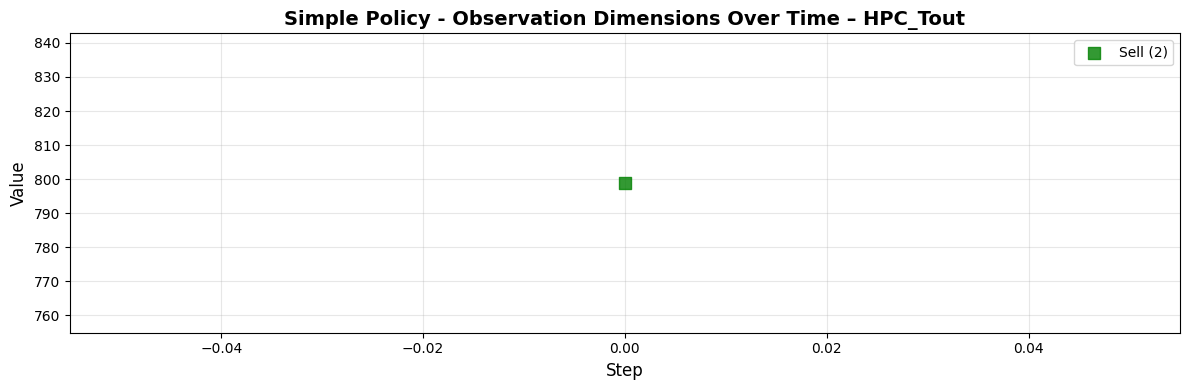

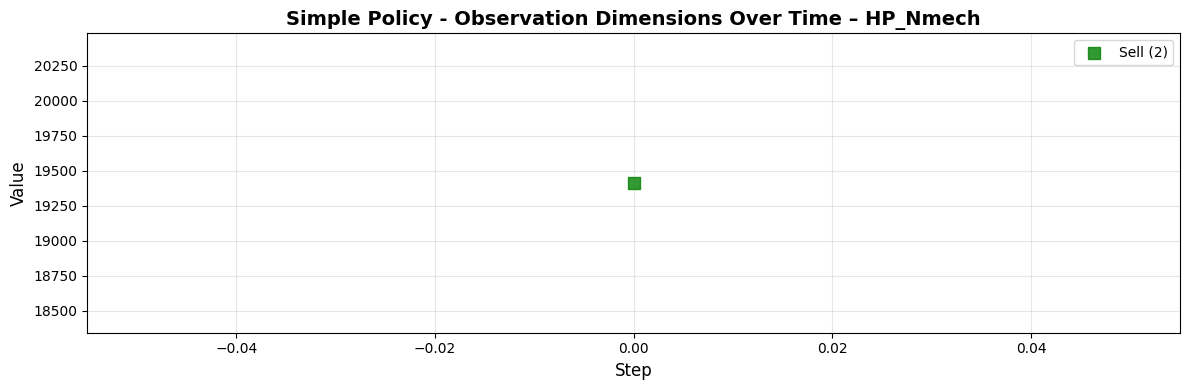

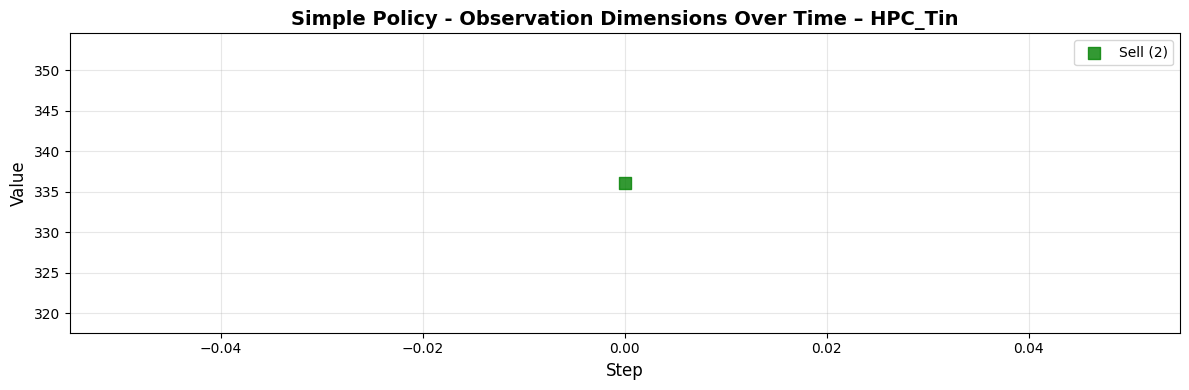

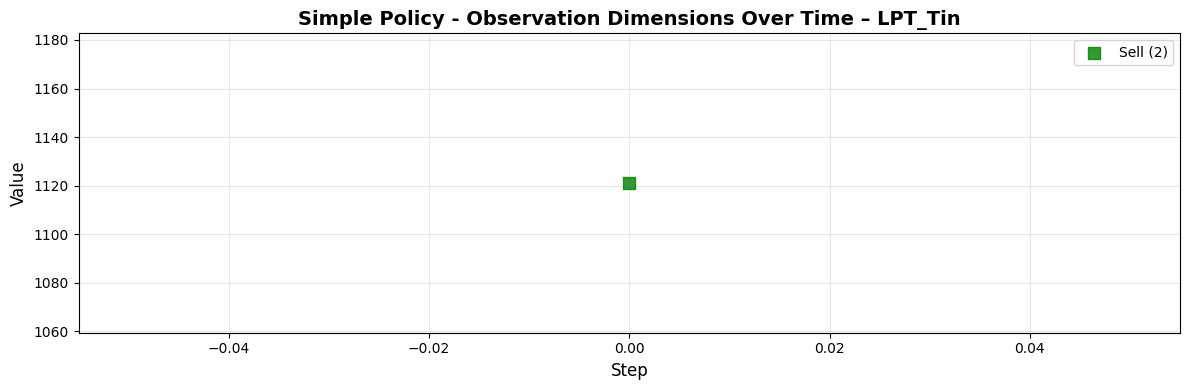

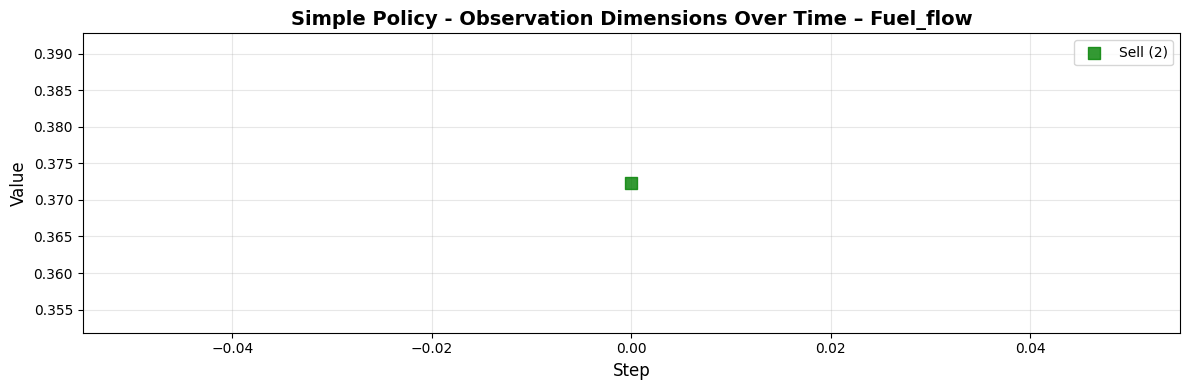

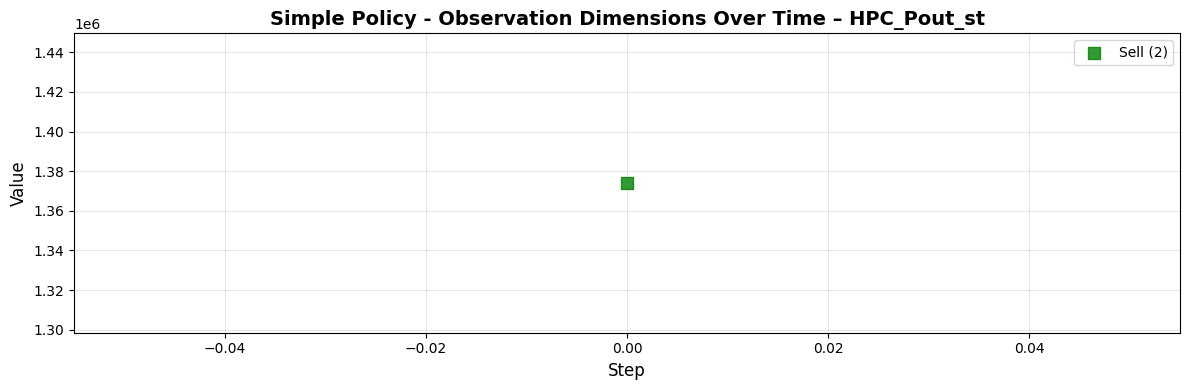

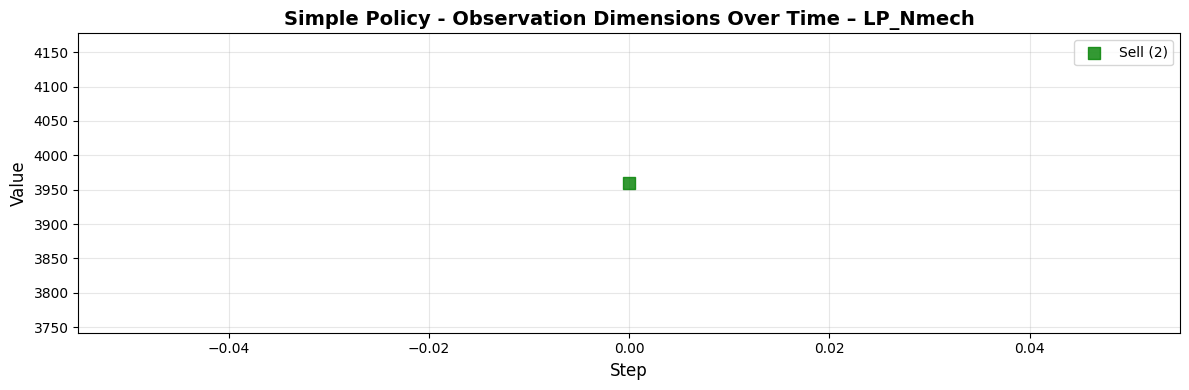

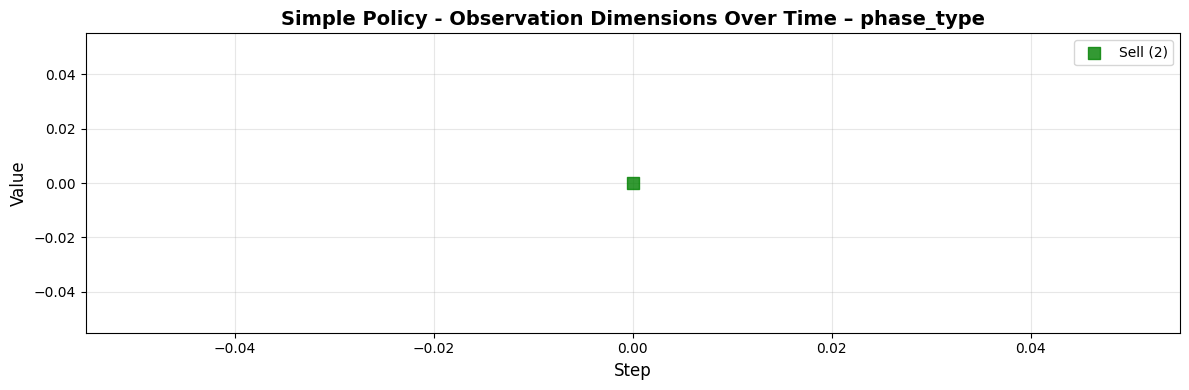

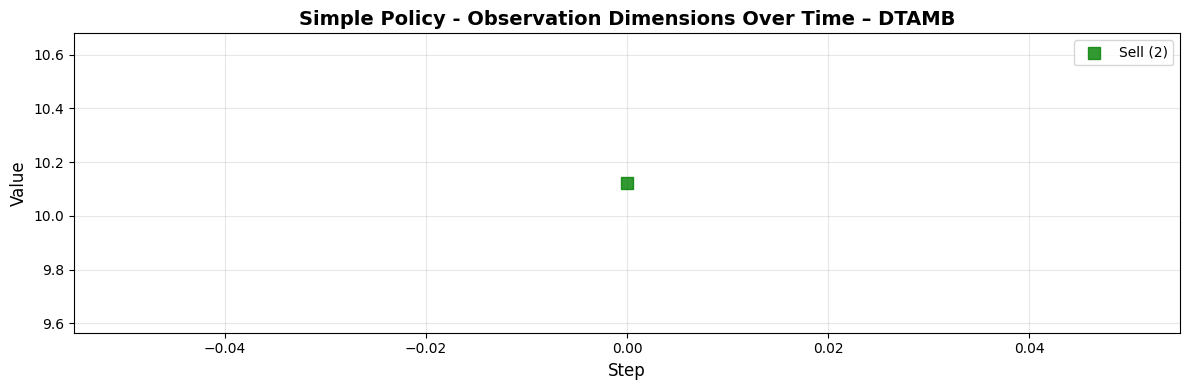

In [14]:
from student_client.plotting import plot_observations


plot_observations(
        observations=observations,
        actions=actions,
        title="Simple Policy - Observation Dimensions Over Time"
    )

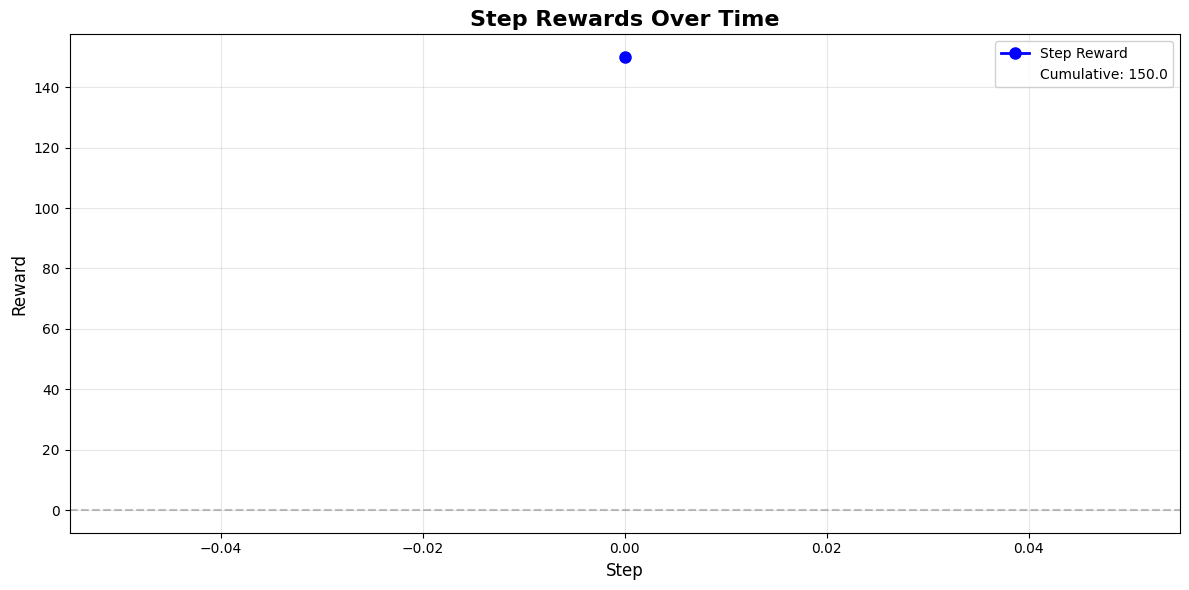

📊 Reward Statistics:
   Total Steps: 1
   Total Reward: 150.00
   Average Reward: 150.00
   Max Reward: 150.00
   Min Reward: 150.00


In [15]:
from student_client.plotting import plot_rewards

plot_rewards(rewards=rewards)